# Run a Single Coupled Example - Dynamic Wflow -> SFINCS

Stage and optionally run one SFINCS event using an accepted dynamic Wflow discharge handoff.

Stage Contract
- Requires: built coupled Wflow/SFINCS bases, Event Catalog, and accepted `sfincs_discharge.dynamic_handoff.json` from `b_prepare_wflow_dynamic_handoff.ipynb`.
- Produces: one staged SFINCS scenario folder, forcing QA plots, optional SFINCS outputs, and post-run diagnostics.
- Next: review diagnostics or batch scenarios in `../05_create_scenarios.ipynb`.


In [1]:
import json
import os
import shutil
import warnings
from pathlib import Path

os.environ.pop("DEBUG", None)
os.environ.setdefault("MPLCONFIGDIR", "/tmp/flood-rm-matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
warnings.filterwarnings("ignore")

import pandas as pd
import xarray as xr
from IPython.display import HTML, Video, display
from hydromt_sfincs import SfincsModel

from sfincs_runs.config import load_runtime
from sfincs_runs.scenarios import (
    configure_hydrograph_initial_conditions,
    plan_inland_coupled_example,
    stage_inland_coupled_scenarios,
)
from sfincs_runs.scenarios.event_forcing import run_sfincs_model
from sfincs_runs.diagnostics import (
    plot_inland_coupled_forcing_qa,
    plot_inland_coupled_postrun_diagnostics,
    plot_inland_flood_animation,
)
from wflow_runs import require_accepted_dynamic_handoff

notebook_root = Path.cwd().resolve()
location_root = notebook_root.parents[1]
repo_root = location_root.parents[1]
config, paths = load_runtime(location_root / "config.yaml")
config["wflow"]["domain_set"]["review_required"] = False

events_root = location_root / config["wflow"].get("events_root", "data/wflow/events")
print(f"location: {location_root.name}  |  root: {location_root}")


location: greensboro  |  root: /home/grahamhults/projects/Flood-RM/locations/greensboro


## 1 - Select a catalog event and verify dynamic Wflow handoff

`plan_inland_coupled_example` checks the static/base-model contract. `require_accepted_dynamic_handoff` checks that the Wflow event replay passed source-id and zero-rain QA before SFINCS staging begins.


In [2]:
EVENT_ID = None  # None -> highest-RP catalog event; or e.g. "design_0398"
CATALOG_PATH = "data/event_catalog/catalog/probability_catalog.csv"

example_plan = plan_inland_coupled_example(
    config,
    {"location_root": location_root},
    catalog_path=CATALOG_PATH,
    event_id=EVENT_ID,
)

plan_summary = pd.Series({
    "status": example_plan.status,
    "event_id": example_plan.event_id,
    "event_reference_time": example_plan.event_reference_time,
    "catalog_path": example_plan.catalog_path,
    "handoff_path": example_plan.handoff_path,
    "wflow_event_dir": example_plan.wflow_event_dir,
    "wflow_discharge_forcing": example_plan.wflow_discharge_forcing,
    "sfincs_scenario_dir": example_plan.sfincs_scenario_dir,
    "sfincs_dry_run_command": example_plan.sfincs_dry_run_command,
}, name="inland_coupled_example_plan")
display(plan_summary)

if example_plan.issues:
    print("Blocking issues (resolve upstream, then rerun):")
    for issue in example_plan.issues:
        print("  -", issue)
if example_plan.status != "ready":
    raise RuntimeError("Coupled example inputs are not ready; resolve the blocking issues above.")

event_id = example_plan.event_id
handoff_acceptance = require_accepted_dynamic_handoff(config, location_root, event_id)
display(handoff_acceptance)

discharge_nc = events_root / event_id / "sfincs_discharge.nc"
event_precip_nc = events_root / event_id / "precip.nc"


status                                                                 ready
event_id                                                         design_0398
event_reference_time                                     2020-11-14T00:00:00
catalog_path               /home/grahamhults/projects/Flood-RM/locations/...
handoff_path               /home/grahamhults/projects/Flood-RM/locations/...
wflow_event_dir                                data/wflow/events/design_0398
wflow_discharge_forcing    data/wflow/events/design_0398/sfincs_discharge.nc
sfincs_scenario_dir        /home/grahamhults/projects/Flood-RM/locations/...
sfincs_dry_run_command     uv run python -m sfincs_runs.scenarios.run_eve...
Name: inland_coupled_example_plan, dtype: str

event_id                                                            design_0398
status                                                                 accepted
discharge_source                                                  wflow_dynamic
sfincs_discharge_forcing      /home/grahamhults/projects/Flood-RM/locations/...
dynamic_handoff_acceptance    /home/grahamhults/projects/Flood-RM/locations/...
Name: dynamic_wflow_handoff_acceptance, dtype: str

## 2 - Configure SFINCS run


In [3]:
config.setdefault("scenario_run", {})["threads"] = 8
run_sfincs_solver = True

display(pd.Series({
    "dynamic_wflow_handoff": "accepted",
    "sfincs_solver": "run" if run_sfincs_solver else "stage forcing only",
    "sfincs_threads": config["scenario_run"]["threads"],
}, name="interactive_model_run"))


dynamic_wflow_handoff    accepted
sfincs_solver                 run
sfincs_threads                  8
Name: interactive_model_run, dtype: object

## 3 - Stage SFINCS and apply rainfall + dynamic Wflow discharge


In [4]:
sim = {}
if not discharge_nc.exists():
    message = f"Missing Wflow discharge forcing: {discharge_nc}."
    raise FileNotFoundError(message + " Run `b_prepare_wflow_dynamic_handoff.ipynb` before staging SFINCS.")
else:
    scenario_report = stage_inland_coupled_scenarios(
        config,
        {"location_root": location_root},
        catalog_path=example_plan.catalog_path,
        event_ids=[event_id],
        force=True,
    )
    display(scenario_report[["event_id", "sfincs_domain_id", "scenario_status", "run_root", "wflow_discharge_forcing"]])

    with xr.open_dataset(discharge_nc) as opened:
        discharge_ds = opened.load()
    t_start = pd.Timestamp(discharge_ds["time"].min().values)
    t_stop = pd.Timestamp(discharge_ds["time"].max().values)
    discharge_by_name = discharge_ds["discharge"].transpose("time", "index").to_pandas()
    discharge_by_name.columns = discharge_ds["name"].values.astype(str)

    direct_rainfall_cfg = config.get("inland_coupling", {}).get("direct_rainfall", {}) or {}
    stage_direct_rainfall = bool(direct_rainfall_cfg.get("enabled", False))
    if stage_direct_rainfall and not event_precip_nc.exists():
        raise FileNotFoundError(f"Missing SFINCS direct rainfall source: {event_precip_nc}. Run `b_prepare_wflow_dynamic_handoff.ipynb` first.")

    sfincs_rows = []
    for _, scenario in scenario_report.iterrows():
        domain_id = str(scenario["sfincs_domain_id"])
        run_dir = Path(scenario["run_root"])

        sf = SfincsModel(root=str(run_dir), mode="r+")
        sf.read()
        sf.config.update({
            "tref": t_start.to_pydatetime(),
            "tstart": t_start.to_pydatetime(),
            "tstop": t_stop.to_pydatetime(),
        })

        prepared_precip = None
        netamprfile = ""
        if stage_direct_rainfall:
            prepared_precip = run_dir / "aorc_precip_for_sfincs.nc"
            shutil.copy2(event_precip_nc, prepared_precip)
            sf.data_catalog.from_dict({
                "event_precip": {
                    "uri": str(prepared_precip),
                    "data_type": "RasterDataset",
                    "driver": {"name": "raster_xarray"},
                    "metadata": {"crs": 4326},
                }
            })
            sf.config.set("precipfile", None)
            sf.config.set("netamprfile", None)
            sf.precipitation.create(
                precip="event_precip",
                buffer=float(direct_rainfall_cfg.get("buffer_m", 30000.0)),
                cumulative_input=bool(direct_rainfall_cfg.get("cumulative_input", True)),
                time_label=str(direct_rainfall_cfg.get("time_label", "right")),
                aggregate=False,
            )
            sf.precipitation.write()
            netamprfile = "sfincs_netampr.nc"

        if sf.discharge_points.nr_points == 0:
            raise RuntimeError(
                f"{run_dir} has no native SFINCS src points. "
                "Rebuild the coupled base so HydroMT-SFINCS rivers.create_river_inflow writes discharge source locations."
            )
        src = sf.discharge_points.gdf
        src_names = src["name"].astype(str).tolist()
        missing_src = sorted(set(src_names) - set(discharge_by_name.columns))
        if missing_src:
            raise RuntimeError(f"Wflow discharge forcing lacks SFINCS src IDs: {missing_src}")
        discharge_df = discharge_by_name[src_names].copy()
        discharge_df.columns = src.index.astype(int)
        sf.discharge_points.create(timeseries=discharge_df, merge=False)
        initial_condition = configure_hydrograph_initial_conditions(
            sf,
            discharge_by_name[src_names],
            config,
            run_dir=run_dir,
        )
        sf.write()

        manifest_path = run_dir / "forcing_manifest.json"
        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        manifest.update({
            "example_notebook": "02_flood/04/c_run_example.ipynb",
            "run_start": t_start.strftime("%Y-%m-%d %H:%M:%S"),
            "run_stop": t_stop.strftime("%Y-%m-%d %H:%M:%S"),
            "sfincs_run_executed": False,
            "wflow_discharge_forcing": str(discharge_nc),
            "wflow_source_variable": config["wflow"].get("handoff", {}).get("source_variable", "river_q"),
            "direct_rainfall_enabled": bool(stage_direct_rainfall),
            "direct_rainfall_source": str(event_precip_nc) if stage_direct_rainfall else "",
            "prepared_precip": str(prepared_precip) if prepared_precip else "",
            "netamprfile": netamprfile,
            "sfincs_initial_condition": initial_condition,
            "direct_rainfall_note": (
                "SFINCS netampr rainfall staged from the same event precipitation used by Wflow."
                if stage_direct_rainfall else "Direct SFINCS rainfall disabled by config."
            ),
        })
        manifest_path.write_text(json.dumps(manifest, indent=2, sort_keys=True) + "\n", encoding="utf-8")

        sim[domain_id] = {
            "run_dir": run_dir,
            "result": None,
            "dis": sf.discharge_points.data["dis"],
            "t_start": t_start,
        }
        sfincs_rows.append({
            "event_id": event_id,
            "sfincs_domain_id": domain_id,
            "status": "staged",
            "n_src": sf.discharge_points.nr_points,
            "run_root": str(run_dir),
            "wflow_discharge_forcing": str(discharge_nc),
            "map_written": False,
        })

    sfincs_report = pd.DataFrame(sfincs_rows)
    display(sfincs_report[["event_id", "sfincs_domain_id", "status", "n_src", "run_root", "wflow_discharge_forcing"]])
    for _, row in sfincs_report.iterrows():
        print(f"{row['sfincs_domain_id']}: staged forcing written; run pre-run QA before launching SFINCS.")


,event_id,sfincs_domain_id,scenario_status,run_root,wflow_discharge_forcing
0,design_0398,greensboro_rural,written,/home/grahamhults/projects/Flood-RM/locations/...,data/wflow/events/design_0398/sfincs_discharge.nc


2026-06-20 15:40:11,629 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc1).
2026-06-20 15:40:11,630 - hydromt.model.model - model - WARNING - No region component found in components.
2026-06-20 15:40:11,728 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask
2026-06-20 15:40:11,730 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: dep
2026-06-20 15:40:11,731 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: manning
2026-06-20 15:40:11,733 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: smax
2026-06-20 15:40:11,734 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: seff
2026-06-20 15:40:11,735 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: ks
2026-06-20 15:40:12,948 - hydromt.hydromt_sfincs.components.output - output - WARNING - File /home/grahamhults/projects/Flood-RM/locations/greensboro/data/sfincs/scenarios

,event_id,sfincs_domain_id,status,n_src,run_root,wflow_discharge_forcing
0,design_0398,greensboro_rural,staged,3,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...


greensboro_rural: staged forcing written; run pre-run QA before launching SFINCS.


## 4 - Pre-run forcing QA


event                                         design_0398 · greensboro_rural
run_root                   /home/grahamhults/projects/Flood-RM/locations/...
forcing_mode                                            dual_fluvial_pluvial
direct_rainfall_enabled                                                 True
wflow_discharge_forcing    /home/grahamhults/projects/Flood-RM/locations/...
rainfall_member_id                          rainfall_greensboro_72h_rank0003
soil_moisture_member_id                        soil_moisture_20080824T120000
Name: inland_forcing_summary, dtype: object

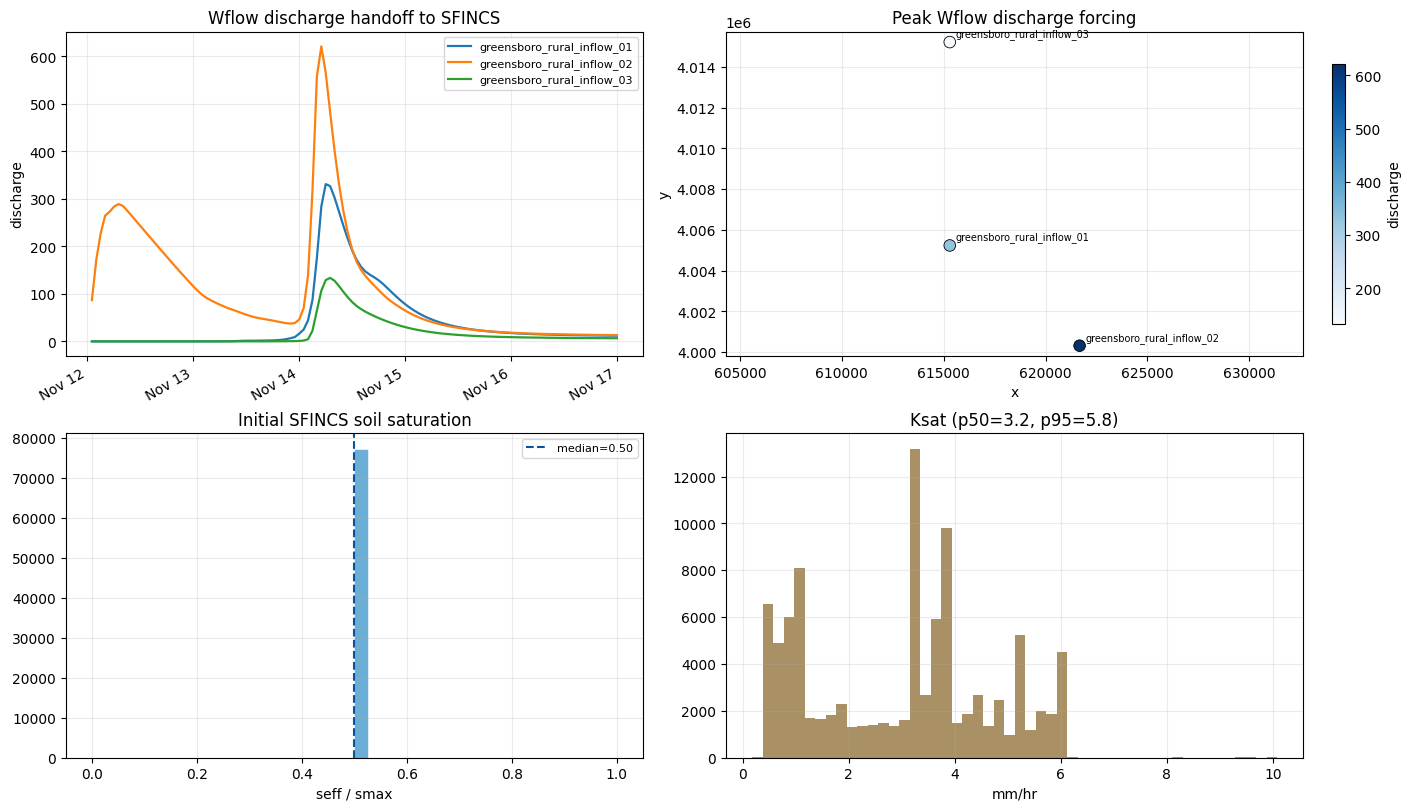

Saved inland forcing QA plot: /home/grahamhults/projects/Flood-RM/locations/greensboro/data/sfincs/scenarios/design_0398/greensboro_rural/diagnostics/design_0398_inland_forcing_qa.png


In [5]:
for domain_id, s in sim.items():
    plot_inland_coupled_forcing_qa(
        forcing_manifest=s["run_dir"] / "forcing_manifest.json",
        event_id=event_id,
        event_label=f"{event_id} · {domain_id}",
    )

if not sim:
    print("No example runs — nothing to QA.")


## 5 - Run SFINCS


In [6]:
if run_sfincs_solver:
    sfincs_rows = []
    for domain_id, s in sim.items():
        run_dir = s["run_dir"]
        result = run_sfincs_model(run_dir, config=config)
        s["result"] = result
        manifest_path = run_dir / "forcing_manifest.json"
        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        manifest["sfincs_run_executed"] = True
        manifest_path.write_text(json.dumps(manifest, indent=2, sort_keys=True) + "\n", encoding="utf-8")
        sfincs_rows.append({
            "event_id": event_id,
            "sfincs_domain_id": domain_id,
            "status": "completed",
            "n_src": int(s["dis"].sizes.get("index", 0)),
            "run_root": str(run_dir),
            "map_written": result.map_path.exists(),
        })
    sfincs_run_report = pd.DataFrame(sfincs_rows)
    display(sfincs_run_report[["event_id", "sfincs_domain_id", "status", "n_src", "run_root", "map_written"]])
else:
    print("SFINCS solver skipped; staged forcing and QA are available for review.")


,event_id,sfincs_domain_id,status,n_src,run_root,map_written
0,design_0398,greensboro_rural,completed,3,/home/grahamhults/projects/Flood-RM/locations/...,True


## 6 - Flood + discharge animation (mp4)


Frames: 120
Peak flooded area: 54.80 km² at 2020-11-14 10:00:00
Peak inflow: 1025.5 m³/s
Display depth threshold: 5 cm  (HUTHRESH=2 cm)


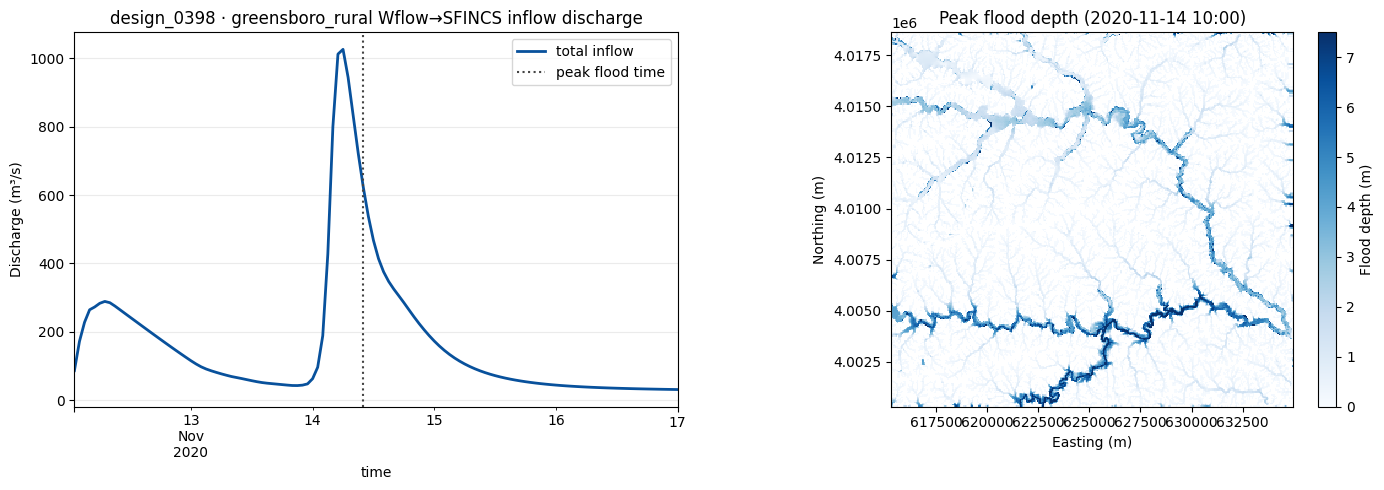

Saved animation: /home/grahamhults/projects/Flood-RM/locations/greensboro/data/sfincs/scenarios/design_0398/greensboro_rural/figures/design_0398_flood_discharge_animation.mp4


In [7]:
for domain_id, s in sim.items():
    discharge_df = s["dis"].transpose("time", "index").to_pandas()
    out_mp4 = plot_inland_flood_animation(
        run_root=s["run_dir"],
        out_dir=s["run_dir"] / "figures",
        event_id=event_id,
        event_label=f"{event_id} · {domain_id}",
        discharge=discharge_df,
        t_start=s["t_start"],
    )
    display(HTML(f"<h4>{event_id} · {domain_id} — flood + discharge animation</h4>"))
    display(Video(str(out_mp4), embed=True))

if not sim:
    print("No example runs — nothing to animate.")
